# Plot OCI Aerosol Data: Aot_865 nm and Angstrom Exponents
Note: This was notebook was the last script I wrote before wrapping up summer analysis. It is a base I was using to begin to dive into the atmospheric products from PACE.
***

In [3]:
# First, import all necessary libraries, modules, and packages. Earthaccess is essential since we will need this to pull PACE data for our analyses
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib.animation as animation
import os
from PIL import Image, ImageEnhance
import cmocean
import scipy.stats as scipy
import pandas as pd
import matplotlib.patches as mpatches

In [4]:
# create datasets 
df_aot = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/aot_PACE_timeseries_8D_PACE_OCI_L2_AOP.csv')
df_aot = df_aot.drop(columns = 'Unnamed: 0')
df_ang = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/angstrom_PACE_timeseries_8D_PACE_OCI_L2_AOP.csv')
df_ang = df_ang.drop(columns = {'Unnamed: 0', 'angstrom geometric mean', 'angstrom geometric std'})
df_aot[:47]

,start date,start year,start month,start day,start time,end time,aot_865 mean,aot_865 geometric mean,aot_865 median,aot_865 std,aot_865 geometric std,aot_865 variance,aot_865 N
0,2025-01-04,2025,1,4,20:23:21.141Z,20:28:21.024Z,0.126949,0.110385,0.11870,0.062282,1.746993,0.003879,37504
1,2025-01-04,2025,1,4,22:01:41.228Z,22:06:40.935Z,0.060780,0.056582,0.06310,0.020965,1.491472,0.000440,1015
2,2025-01-05,2025,1,5,20:58:06.123Z,21:03:06.006Z,0.092942,0.082258,0.07150,0.051877,1.600298,0.002691,181039
3,2025-01-06,2025,1,6,19:54:26.105Z,19:59:25.987Z,0.077965,0.073693,0.07260,0.026494,1.398327,0.000702,10868
4,2025-01-06,2025,1,6,21:32:45.139Z,21:37:45.021Z,0.066903,0.063228,0.06310,0.022536,1.401453,0.000508,7596
5,2025-01-07,2025,1,7,20:29:10.209Z,20:34:09.916Z,0.162275,0.148176,0.15440,0.066245,1.553913,0.004388,43635
6,2025-01-07,2025,1,7,22:07:29.068Z,22:12:28.950Z,0.078629,0.078450,0.07910,0.005322,1.075312,0.000028,7
7,2025-01-08,2025,1,8,21:03:54.138Z,21:08:54.021Z,0.084368,0.076878,0.07430,0.040032,1.519799,0.001603,236666
8,2025-01-09,2025,1,9,20:00:19.209Z,20:05:18.916Z,0.055652,0.050210,0.05850,0.023152,1.610850,0.000536,29420
9,2025-01-09,2025,1,9,21:38:38.067Z,21:43:37.950Z,0.066726,0.060906,0.06610,0.025833,1.582929,0.000667,65484


In [5]:
df_aot_fix = df_aot[:47]
#df_aot_fix

In [6]:
df = pd.concat([df_aot_fix, df_ang], axis=1)
#df

In [7]:
# identify a threshold based on the sample size (N)
threshold = np.median(df['aot_865 N'])
print(f'Threshold: {threshold}')

# create a filtered dataframe populated with data that is >= the threshold
filtered_df = df.loc[df['aot_865 N'] >= threshold]
filtered_df.reset_index(inplace=True)
filtered_df = filtered_df.dropna()
# remove duplicate columns, keep only first occurrence since dates align
filtered_df = filtered_df.loc[:, ~filtered_df.columns.duplicated()]
filtered_df

Threshold: 22020.0


,index,start date,start year,start month,start day,start time,end time,aot_865 mean,aot_865 geometric mean,aot_865 median,aot_865 std,aot_865 geometric std,aot_865 variance,aot_865 N,angstrom mean,angstrom median,angstrom std,angstrom variance,angstrom N
0,0,2025-01-04,2025,1,4,20:23:21.141Z,20:28:21.024Z,0.126949,0.110385,0.1187,0.062282,1.746993,0.003879,37504,0.343471,0.19120,0.374162,0.139997,37504
1,2,2025-01-05,2025,1,5,20:58:06.123Z,21:03:06.006Z,0.092942,0.082258,0.0715,0.051877,1.600298,0.002691,181039,0.224970,0.25050,0.402202,0.161767,180937
2,5,2025-01-07,2025,1,7,20:29:10.209Z,20:34:09.916Z,0.162275,0.148176,0.1544,0.066245,1.553913,0.004388,43635,0.289414,0.26770,0.235386,0.055406,43635
3,7,2025-01-08,2025,1,8,21:03:54.138Z,21:08:54.021Z,0.084368,0.076878,0.0743,0.040032,1.519799,0.001603,236666,0.504834,0.44220,0.444133,0.197254,236420
4,8,2025-01-09,2025,1,9,20:00:19.209Z,20:05:18.916Z,0.055652,0.050210,0.0585,0.023152,1.610850,0.000536,29420,0.655292,0.71470,0.347207,0.120553,29420
5,9,2025-01-09,2025,1,9,21:38:38.067Z,21:43:37.950Z,0.066726,0.060906,0.0661,0.025833,1.582929,0.000667,65484,0.685950,0.69505,0.374045,0.139910,65484
6,10,2025-01-10,2025,1,10,20:35:03.138Z,20:40:03.020Z,0.076438,0.062250,0.0519,0.056945,1.828330,0.003243,162849,0.906728,0.95470,0.457107,0.208947,162849
8,12,2025-01-12,2025,1,12,20:06:11.084Z,20:11:10.967Z,0.081504,0.078337,0.0780,0.022710,1.329084,0.000516,44096,0.330047,0.31670,0.233975,0.054744,44096
9,14,2025-01-13,2025,1,13,20:40:49.222Z,20:45:48.929Z,0.111199,0.090564,0.0937,0.069324,1.932925,0.004806,45419,0.708789,0.68960,0.385392,0.148527,45419
10,15,2025-01-14,2025,1,14,21:15:32.098Z,21:20:31.981Z,0.061955,0.054390,0.0543,0.031765,1.681637,0.001009,107264,0.832296,0.86230,0.387260,0.149970,107205


In [8]:
# group data by the day
filtered_df = filtered_df.groupby('start date').mean(numeric_only=True)
filtered_df.reset_index(inplace=True)
filtered_df

,start date,index,start year,start month,start day,aot_865 mean,aot_865 geometric mean,aot_865 median,aot_865 std,aot_865 geometric std,aot_865 variance,aot_865 N,angstrom mean,angstrom median,angstrom std,angstrom variance,angstrom N
0,2025-01-04,0.0,2025.0,1.0,4.0,0.126949,0.110385,0.11870,0.062282,1.746993,0.003879,37504.0,0.343471,0.191200,0.374162,0.139997,37504.0
1,2025-01-05,2.0,2025.0,1.0,5.0,0.092942,0.082258,0.07150,0.051877,1.600298,0.002691,181039.0,0.224970,0.250500,0.402202,0.161767,180937.0
2,2025-01-07,5.0,2025.0,1.0,7.0,0.162275,0.148176,0.15440,0.066245,1.553913,0.004388,43635.0,0.289414,0.267700,0.235386,0.055406,43635.0
3,2025-01-08,7.0,2025.0,1.0,8.0,0.084368,0.076878,0.07430,0.040032,1.519799,0.001603,236666.0,0.504834,0.442200,0.444133,0.197254,236420.0
4,2025-01-09,8.5,2025.0,1.0,9.0,0.061189,0.055558,0.06230,0.024493,1.596889,0.000602,47452.0,0.670621,0.704875,0.360626,0.130231,47452.0
5,2025-01-10,10.0,2025.0,1.0,10.0,0.076438,0.062250,0.05190,0.056945,1.828330,0.003243,162849.0,0.906728,0.954700,0.457107,0.208947,162849.0
6,2025-01-12,12.0,2025.0,1.0,12.0,0.081504,0.078337,0.07800,0.022710,1.329084,0.000516,44096.0,0.330047,0.316700,0.233975,0.054744,44096.0
7,2025-01-13,14.0,2025.0,1.0,13.0,0.111199,0.090564,0.09370,0.069324,1.932925,0.004806,45419.0,0.708789,0.689600,0.385392,0.148527,45419.0
8,2025-01-14,15.0,2025.0,1.0,14.0,0.061955,0.054390,0.05430,0.031765,1.681637,0.001009,107264.0,0.832296,0.862300,0.387260,0.149970,107205.0
9,2025-01-15,16.5,2025.0,1.0,15.0,0.036970,0.030983,0.02515,0.025650,1.725302,0.000669,45715.5,0.653232,0.667350,0.297539,0.088743,45715.5


<ErrorbarContainer object of 3 artists>

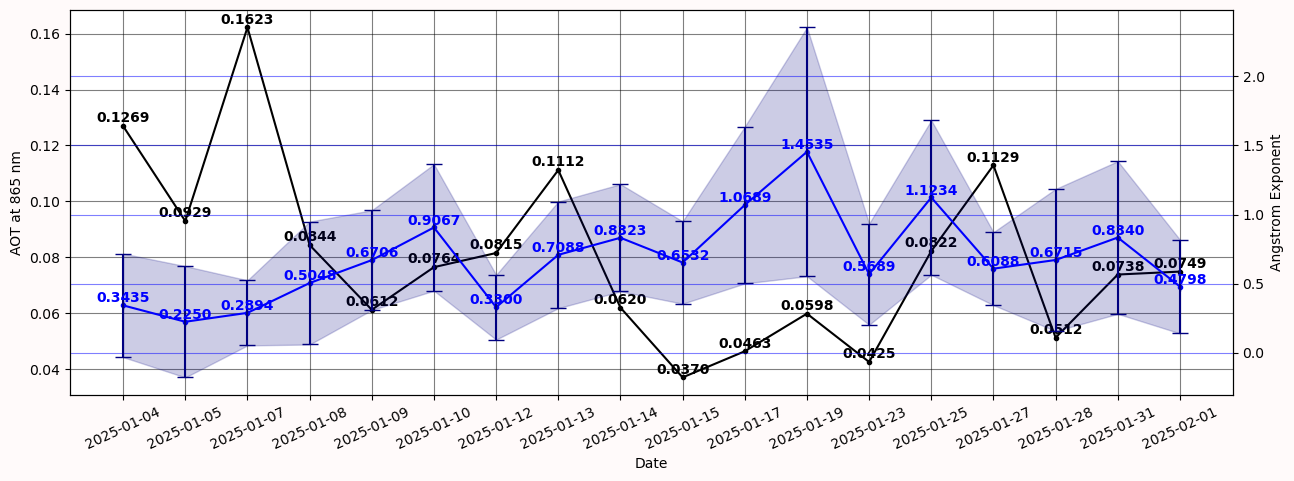

In [33]:
aot_mean = filtered_df['aot_865 mean'].values.copy()
ang_mean = filtered_df['angstrom mean'].values.copy()
date = filtered_df['start date'].copy()

fig = plt.figure(figsize=(15,5), facecolor = 'snow')
plt.plot(date, aot_mean, color = 'k', marker='.')
plt.grid(True, color='k', alpha=0.5)
plt.ylabel('AOT at 865 nm')
plt.xlabel('Date')
plt.tick_params(axis='x',rotation=25)
for x, y in zip(date, aot_mean):
    plt.text(x, y + 0.0003, f'{y:.4f}', ha='center', va='bottom', fontsize=10, color='k', fontweight = 'bold')
#plt.fill_between(date, aot_mean - filtered_df['aot_865 std'], aot_mean + filtered_df['aot_865 std'], color='slategrey', alpha=0.2, label='2012–2025 ± 1 Std')
#plt.errorbar(date,aot_mean,yerr=filtered_df['aot_865 std'], fmt='|', capsize=6, color = 'black')

ax1=plt.twinx()
ax1.plot(date, ang_mean, color = 'b',marker='.')
ax1.set_ylabel('Angstrom Exponent')
#plt.xticks(date[::2])
ax1.grid(True,color ='b',alpha=0.5)
for x, y in zip(date, ang_mean):
    ax1.text(x, y + 0.0003, f'{y:.4f}', ha='center', va='bottom', fontsize=10, color='b', fontweight = 'bold')
#ax1.fill_between(date, ang_mean - filtered_df['angstrom std'], ang_mean + filtered_df['angstrom std'], color='navy', alpha=0.2, label='2012–2025 ± 1 Std')
#ax1.errorbar(date,ang_mean,yerr=filtered_df['angstrom std'], fmt='|', capsize=6, color = 'navy')

# highlight TOI
# plt.axvline('2025-01-07', linestyle = '--')
# plt.axvspan('2025-01-07', '2025-01-31', color = 'gold', alpha=0.3)

# shading +-1 std
#plt.plot(mean_chla.index, mean_chla - std_chla, color='lightsteelblue', linewidth=0.8, alpha=0.5)
#plt.plot(mean_chla.index, mean_chla + std_chla, color='lightsteelblue', linewidth=0.8, alpha=0.5)
    
#plt.legend(loc = 'upper right', fontsize = 12)